# 02 · Análisis exploratorio

Proyecto de titulación · Maestría en Inteligencia Artificial Aplicada (UDLA)
Amapola Technologies Corp.

Este notebook explora el dataset construido en la fase anterior, el cual contiene 21.642 cliente-mes
correspondientes a 10.452 clientes entre julio de 2025 y abril de 2026. El propósito es responder
tres preguntas antes de pasar al modelado:

- Cómo se comporta la variable objetivo, es decir, su distribución, su estabilidad a lo largo del
  período y su relación con el proxy `cumplimiento_ceroteo` que la empresa venía utilizando.
- Qué variables discriminan, para lo cual se calcula la tasa de cumplimiento por cada predictora
  acompañada de intervalos de confianza, dado que los grupos tienen tamaños muy distintos.
- Qué inconvenientes presenta el dataset, entre ellos el sesgo de selección en la cobertura
  conversacional, los meses atípicos y las variables con nulos estructurales.

Las figuras se guardan en `outputs/figuras/`. Cabe aclarar que cada una va acompañada de su tabla de
respaldo, de modo que ningún valor deba leerse únicamente del gráfico.

## 0 · Configuración y estilo

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_OUTPUTS = RAIZ / "outputs"
DIR_FIGURAS = DIR_OUTPUTS / "figuras"
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

RUTA_DATASET = DIR_OUTPUTS / "dataset_clientemes_v1.csv"
print("Dataset:", RUTA_DATASET, "| existe:", RUTA_DATASET.exists())

Dataset: C:\mia_capstone\outputs\dataset_clientemes_v1.csv | existe: True


### 0.1 · Paleta

Paleta categórica validada para daltonismo (peor par all-pairs: ΔE 9,2 deutan / 24,0 visión
normal, sobre superficie clara `#fcfcfb`). El aqua queda en 2,74:1 de contraste, por debajo de
3:1, motivo por el cual siempre lleva etiqueta visible y no depende únicamente del color.

Reglas aplicadas en todo el notebook: una serie → un solo color; magnitud → un solo tono
azul de claro a oscuro; correlaciones → divergente azul↔rojo con gris neutro en el cero;
rejilla y ejes en hairline sólido; sin dobles ejes.

In [2]:
# Categórica (slots en orden fijo, nunca ciclados)
AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
# Chrome
SUPERFICIE = "#fcfcfb"
TINTA = "#0b0b0b"
TINTA_2 = "#52514e"
MUTED = "#898781"
REJILLA = "#e1e0d9"
EJE = "#c3c2b7"

mpl.rcParams.update({
    "figure.facecolor": SUPERFICIE,
    "axes.facecolor": SUPERFICIE,
    "savefig.facecolor": SUPERFICIE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "sans-serif"],
    "font.size": 10,
    "text.color": TINTA,
    "axes.labelcolor": TINTA_2,
    "axes.edgecolor": EJE,
    "axes.linewidth": 0.8,
    "axes.titlesize": 12,
    "axes.titleweight": "600",
    "axes.titlecolor": TINTA,
    "axes.titlepad": 12,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": REJILLA,
    "grid.linewidth": 0.8,
    "grid.linestyle": "-",          # hairline solido, nunca punteado
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
})

def limpiar(ax, eje_x=True, eje_y=False):
    """Quita marco superior/derecho y deja la rejilla en un solo eje."""
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    ax.spines["left"].set_color(EJE)
    ax.spines["bottom"].set_color(EJE)
    ax.grid(axis="y" if eje_x else "x", color=REJILLA, linewidth=0.8)
    ax.grid(axis="x" if eje_x else "y", visible=eje_y)
    ax.tick_params(length=0)
    return ax

def titulos(ax, titulo, subtitulo=None):
    """Título y subtítulo apilados sobre el eje, sin que se pisen entre sí."""
    if subtitulo:
        ax.text(0, 1.13, titulo, transform=ax.transAxes, fontsize=12,
                fontweight="600", color=TINTA, va="bottom")
        ax.text(0, 1.035, subtitulo, transform=ax.transAxes, fontsize=9,
                color=MUTED, va="bottom")
    else:
        ax.text(0, 1.035, titulo, transform=ax.transAxes, fontsize=12,
                fontweight="600", color=TINTA, va="bottom")

def guardar(fig, nombre):
    ruta = DIR_FIGURAS / f"{nombre}.png"
    fig.savefig(ruta)
    print(f"figura -> {ruta.relative_to(RAIZ)}")

### 0.2 · Tasa con intervalo de confianza

Las tasas de cumplimiento se comparan entre grupos de tamaño muy distinto, ya que un bucket puede
tener 62 registros y otro más de nueve mil. Sin intervalo de confianza resulta fácil interpretar
como señal lo que solamente es ruido de muestra pequeña.

Se utiliza el intervalo de Wilson al 95 %, dado que se comporta mejor que el intervalo normal
clásico con proporciones extremas y muestras reducidas.

In [3]:
def wilson(exitos, n, z=1.96):
    """Intervalo de confianza de Wilson para una proporción."""
    if n == 0:
        return (np.nan, np.nan)
    p = exitos / n
    d = 1 + z**2 / n
    centro = (p + z**2 / (2 * n)) / d
    margen = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return (max(0.0, centro - margen), min(1.0, centro + margen))


def tasa_por(df, columna, target="cumplimiento_conciliado", min_n=0):
    """Tabla de tasa de cumplimiento por categoría, con n e IC de Wilson."""
    g = (df.groupby(columna, dropna=False)[target]
           .agg(n="size", cumplen="sum")
           .reset_index())
    g["tasa"] = g["cumplen"] / g["n"]
    ic = g.apply(lambda r: wilson(r["cumplen"], r["n"]), axis=1)
    g["ic_bajo"] = [a for a, _ in ic]
    g["ic_alto"] = [b for _, b in ic]
    g["err_bajo"] = g["tasa"] - g["ic_bajo"]
    g["err_alto"] = g["ic_alto"] - g["tasa"]
    return g[g["n"] >= min_n].reset_index(drop=True)


def barras_tasa(tabla, columna, titulo, nombre_fig, horizontal=False,
                color=AZUL, subtitulo=None, ordenar=False):
    """Barras de tasa con IC de Wilson y etiqueta directa de valor y n."""
    t = tabla.sort_values("tasa", ascending=True) if ordenar else tabla
    # pandas 3.0 conserva NA en astype(str): las categorías nulas se etiquetan a mano
    etiquetas = ["(sin dato)" if pd.isna(v) else str(v) for v in t[columna]]
    alto = max(3.0, 0.42 * len(t) + 1.6) if horizontal else 4.2
    fig, ax = plt.subplots(figsize=(9, alto))

    if horizontal:
        ax.barh(etiquetas, t["tasa"], height=0.62, color=color,
                xerr=[t["err_bajo"], t["err_alto"]],
                error_kw=dict(ecolor=MUTED, elinewidth=1, capsize=3))
        limpiar(ax, eje_x=False)
        ax.set_xlabel("Tasa de cumplimiento")
        ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
        for y, (v, n) in enumerate(zip(t["tasa"], t["n"])):
            ax.text(v + t["err_alto"].iloc[y] + 0.012, y, f"{v:.1%}  (n={n:,})",
                    va="center", fontsize=9, color=TINTA_2)
        ax.set_xlim(0, min(1.0, (t["ic_alto"].max() + 0.14)))
    else:
        ax.bar(etiquetas, t["tasa"], width=0.62, color=color,
               yerr=[t["err_bajo"], t["err_alto"]],
               error_kw=dict(ecolor=MUTED, elinewidth=1, capsize=3))
        limpiar(ax, eje_x=True)
        ax.set_ylabel("Tasa de cumplimiento")
        ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
        for x, (v, n) in enumerate(zip(t["tasa"], t["n"])):
            ax.text(x, v + t["err_alto"].iloc[x] + 0.008, f"{v:.1%}\nn={n:,}",
                    ha="center", va="bottom", fontsize=8, color=TINTA_2)
        ax.set_ylim(0, min(1.0, t["ic_alto"].max() + 0.12))

    titulos(ax, titulo, subtitulo)
    guardar(fig, nombre_fig)
    plt.show()

---
## 1 · Carga y perfil general

In [4]:
df = pd.read_csv(RUTA_DATASET, dtype={"mes": str, "id_anonimo": str})

TARGET = "cumplimiento_conciliado"
PROXY = "cumplimiento_ceroteo"
PREDICTORAS = [
    "total_intenciones", "intenciones_distintas", "activo_compromiso", "dias_compromiso",
    "activo_ya_pague", "ultima_intencion_antes_compromiso", "hora_primera_interaccion",
    "dia_semana_primera_interaccion", "dias_mora_inicial", "meses_consecutivos_mora",
]
CONTEXTO = ["tipo_operacion", "bucket", "mes_campania", "lote_control", "tiene_conversacion"]

print("Dimensiones :", df.shape)
print("Clientes    :", df["id_anonimo"].nunique())
print("Meses       :", df["mes"].nunique(), f"({df['mes'].min()} - {df['mes'].max()})")
print("Duplicados  :", int(df.duplicated(["id_anonimo", "mes"]).sum()))
print("Memoria     :", f"{df.memory_usage(deep=True).sum()/1e6:.1f} MB")
display(df.head())

Dimensiones : (21642, 19)
Clientes    : 10452
Meses       : 10 (202507 - 202604)
Duplicados  : 0
Memoria     : 5.2 MB


,id_anonimo,mes,total_intenciones,intenciones_distintas,activo_compromiso,dias_compromiso,activo_ya_pague,ultima_intencion_antes_compromiso,hora_primera_interaccion,dia_semana_primera_interaccion,dias_mora_inicial,meses_consecutivos_mora,tipo_operacion,bucket,mes_campania,lote_control,tiene_conversacion,cumplimiento_conciliado,cumplimiento_ceroteo
0,49654de2105d1f06e020a2c249ebd91acbd29386243bf8...,202604,2,2,1,1.0,0,SIN_PREVIA,21.0,1.0,35,1,TC,B2,17.0,57,1,0,1
1,6dbc81b965ac2689d337e5018601ec233e35fa3530eccd...,202602,0,0,0,NaN,0,SIN_DATOS,NaN,NaN,81,1,TC,B3,15.0,53_ad,0,0,0
2,6dbc81b965ac2689d337e5018601ec233e35fa3530eccd...,202603,0,0,0,NaN,0,SIN_DATOS,NaN,NaN,88,2,TC,B3,15.0,53_ad,0,0,0
3,8df2fe9cf302666604e6ac711b2c1f9bd37b59a704a9f1...,202509,0,0,0,NaN,0,SIN_DATOS,NaN,NaN,21,1,TC,B1,9.0,39,0,1,1
4,8df2fe9cf302666604e6ac711b2c1f9bd37b59a704a9f1...,202510,0,0,0,NaN,0,SIN_DATOS,NaN,NaN,0,0,TC,B0,9.0,39,0,0,1


In [5]:
perfil = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "%_nulos": (df.isna().mean() * 100).round(2),
    "unicos": df.nunique(),
    "rol": ["target" if c in (TARGET, PROXY)
            else "predictora" if c in PREDICTORAS
            else "contexto" if c in CONTEXTO
            else "identificador" for c in df.columns],
})
display(perfil)

print("Los nulos son estructurales, no faltantes:")
print(f"  dias_compromiso                : {df['dias_compromiso'].isna().mean():.1%} "
      "-> no hubo compromiso registrado en prod_compromisos")
print(f"  hora / dia_semana              : {df['hora_primera_interaccion'].isna().mean():.1%} "
      "-> el cliente-mes no tuvo conversacion")
print(f"  bucket                         : {df['bucket'].isna().mean():.1%}")
print("XGBoost maneja NaN de forma nativa: no se imputan.")

,tipo,nulos,%_nulos,unicos,rol
id_anonimo,str,0,0.00,10452,identificador
mes,str,0,0.00,10,identificador
total_intenciones,int64,0,0.00,40,predictora
intenciones_distintas,int64,0,0.00,17,predictora
activo_compromiso,int64,0,0.00,2,predictora
dias_compromiso,float64,20534,94.88,4,predictora
activo_ya_pague,int64,0,0.00,2,predictora
ultima_intencion_antes_compromiso,str,0,0.00,27,predictora
hora_primera_interaccion,float64,15901,73.47,24,predictora
dia_semana_primera_interaccion,float64,15901,73.47,7,predictora


Los nulos son estructurales, no faltantes:
  dias_compromiso                : 94.9% -> no hubo compromiso registrado en prod_compromisos
  hora / dia_semana              : 73.5% -> el cliente-mes no tuvo conversacion
  bucket                         : 0.8%
XGBoost maneja NaN de forma nativa: no se imputan.


In [6]:
print("Estadisticos de las predictoras numericas:")
numericas = [c for c in PREDICTORAS if pd.api.types.is_numeric_dtype(df[c])]
display(df[numericas].describe().T.round(2))

print("\nCategoricas:")
for c in ["tipo_operacion", "bucket", "ultima_intencion_antes_compromiso"]:
    vc = df[c].value_counts(dropna=False)
    print(f"\n{c} ({df[c].nunique()} valores):")
    print(vc.head(10).to_string())

Estadisticos de las predictoras numericas:


,count,mean,std,min,25%,50%,75%,max
total_intenciones,21642.0,1.03,2.94,0.0,0.0,0.0,1.0,172.0
intenciones_distintas,21642.0,0.72,1.55,0.0,0.0,0.0,1.0,16.0
activo_compromiso,21642.0,0.13,0.33,0.0,0.0,0.0,0.0,1.0
dias_compromiso,1108.0,3.95,1.60,1.0,3.0,5.0,5.0,5.0
activo_ya_pague,21642.0,0.04,0.19,0.0,0.0,0.0,0.0,1.0
hora_primera_interaccion,5741.0,15.20,2.55,0.0,15.0,15.0,16.0,23.0
dia_semana_primera_interaccion,5741.0,2.01,1.36,0.0,1.0,2.0,3.0,6.0
dias_mora_inicial,21642.0,47.44,43.85,0.0,20.0,35.0,57.0,210.0
meses_consecutivos_mora,21642.0,1.52,1.00,0.0,1.0,1.0,2.0,10.0



Categoricas:

tipo_operacion (2 valores):
tipo_operacion
TC         15942
CARTERA     5700

bucket (8 valores):
bucket
B2     8296
B1     7597
B3     1622
B0     1247
B6     1217
B4      751
B5      682
NaN     168
B7       62

ultima_intencion_antes_compromiso (27 valores):
ultima_intencion_antes_compromiso
SIN_DATOS                  15901
NO_APLICA                   3002
SIN_PREVIA                  1419
formas_pago                  914
ahora_no_contact             122
banca_virtual                 70
hablar_asesor                 46
default fallback intent       39
agencia_cercana               30
default welcome intent        24


---
## 2 · El target

In [7]:
n = len(df)
pos = int(df[TARGET].sum())
neg = n - pos
ratio = neg / pos

print("=" * 62)
print("cumplimiento_conciliado (target principal)")
print("=" * 62)
print(f"  positivos        : {pos:,} ({pos/n:.2%})")
print(f"  negativos        : {neg:,} ({neg/n:.2%})")
print(f"  desbalance       : {ratio:.2f} : 1")
print(f"  scale_pos_weight : {ratio:.3f}")
print()
pos2 = int(df[PROXY].sum())
print("cumplimiento_ceroteo (proxy interno)")
print(f"  positivos        : {pos2:,} ({pos2/n:.2%})")
print(f"  scale_pos_weight : {(n - pos2)/pos2:.3f}")

cumplimiento_conciliado (target principal)
  positivos        : 3,827 (17.68%)
  negativos        : 17,815 (82.32%)
  desbalance       : 4.66 : 1
  scale_pos_weight : 4.655

cumplimiento_ceroteo (proxy interno)
  positivos        : 5,264 (24.32%)
  scale_pos_weight : 3.111


figura -> outputs\figuras\00_distribucion_target.png


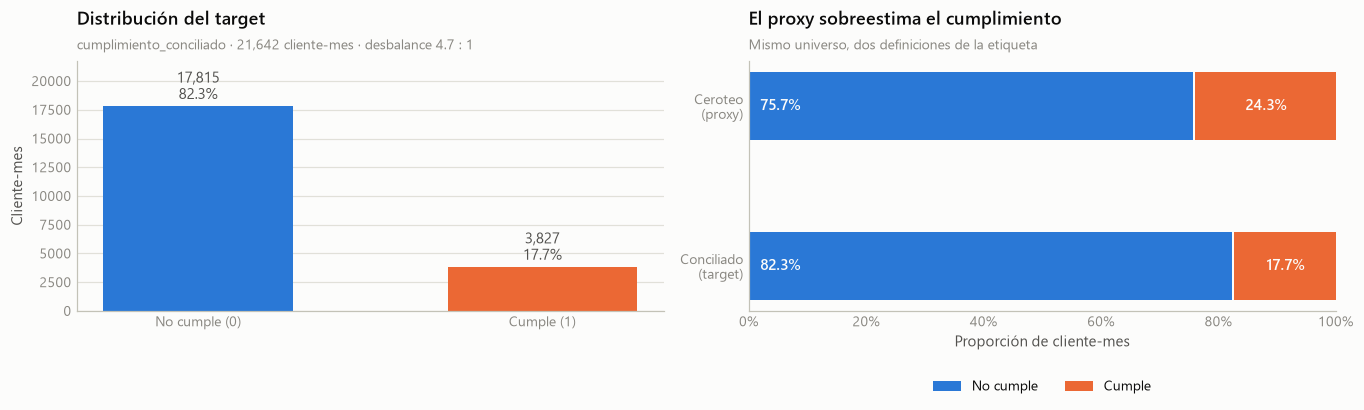

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

# Izquierda: conteo absoluto de las dos clases
ax = axes[0]
conteo = df[TARGET].value_counts().sort_index()
etiquetas = ["No cumple (0)", "Cumple (1)"]
ax.bar(etiquetas, conteo.values, width=0.55, color=[AZUL, NARANJA])
limpiar(ax)
ax.set_ylabel("Cliente-mes")
for i, v in enumerate(conteo.values):
    ax.text(i, v + len(df) * 0.012, f"{v:,}\n{v/len(df):.1%}",
            ha="center", va="bottom", fontsize=10, color=TINTA_2)
ax.set_ylim(0, conteo.max() * 1.22)
titulos(ax, "Distribución del target",
        f"cumplimiento_conciliado · {len(df):,} cliente-mes · desbalance {neg/pos:.1f} : 1")

# Derecha: el target frente al proxy, en proporcion
ax = axes[1]
y = np.arange(2)
alto = 0.42
for k, (col, nombre) in enumerate([(TARGET, "Conciliado (target)"),
                                   (PROXY, "Ceroteo (proxy)")]):
    tasa = df[col].mean()
    ax.barh(k, 1 - tasa, alto, color=AZUL, label="No cumple" if k == 0 else None)
    ax.barh(k, tasa, alto, left=1 - tasa + 0.004, color=NARANJA,
            label="Cumple" if k == 0 else None)
    ax.text(1 - tasa / 2 + 0.004, k, f"{tasa:.1%}", ha="center", va="center",
            fontsize=10, color=SUPERFICIE, fontweight="600")
    ax.text(0.02, k, f"{1-tasa:.1%}", ha="left", va="center",
            fontsize=10, color=SUPERFICIE, fontweight="600")
ax.set_yticks(y)
ax.set_yticklabels(["Conciliado\n(target)", "Ceroteo\n(proxy)"])
limpiar(ax, eje_x=False)
ax.grid(False)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax.set_xlabel("Proporción de cliente-mes")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.38), ncols=2)
titulos(ax, "El proxy sobreestima el cumplimiento",
        "Mismo universo, dos definiciones de la etiqueta")

fig.tight_layout()
guardar(fig, "00_distribucion_target")
plt.show()

### 2.1 · Concordancia entre el target y el proxy

`cumplimiento_ceroteo` (mora en cero al cierre) es la métrica interna que se venía usando.
Interesa saber cuánto se parece al target real (`cumplimiento_conciliado`, pago confirmado por el
banco): si fueran equivalentes, el proxy bastaría y no haría falta la conciliación bancaria.

In [9]:
tabla = pd.crosstab(df[TARGET], df[PROXY],
                    rownames=["conciliado"], colnames=["ceroteo"])
display(tabla)

a, b = tabla.loc[0, 0], tabla.loc[0, 1]
c, d = tabla.loc[1, 0], tabla.loc[1, 1]
acuerdo = (a + d) / n
p_azar = ((a + b) * (a + c) + (c + d) * (b + d)) / n**2
kappa = (acuerdo - p_azar) / (1 - p_azar)

print(f"\nAcuerdo observado : {acuerdo:.1%}")
print(f"Kappa de Cohen    : {kappa:.3f}")
print(f"\nCeroteo=1 pero sin pago conciliado : {b:,} ({b/n:.1%}) -> falsos positivos del proxy")
print(f"Pago conciliado pero ceroteo=0     : {c:,} ({c/n:.1%}) -> pagos parciales")
print("\nEl proxy sobreestima el cumplimiento: la mora llega a cero por refinanciacion,")
print("castigo o ajuste contable, no solo por pago. Confirma usar el target conciliado.")

ceroteo,0,1
conciliado,,
0,15547,2268
1,831,2996



Acuerdo observado : 85.7%
Kappa de Cohen    : 0.571

Ceroteo=1 pero sin pago conciliado : 2,268 (10.5%) -> falsos positivos del proxy
Pago conciliado pero ceroteo=0     : 831 (3.8%) -> pagos parciales

El proxy sobreestima el cumplimiento: la mora llega a cero por refinanciacion,
castigo o ajuste contable, no solo por pago. Confirma usar el target conciliado.


### 2.2 · Estabilidad temporal

In [10]:
mensual = (df.groupby("mes")
             .agg(registros=(TARGET, "size"),
                  cumplen=(TARGET, "sum"),
                  tasa_conciliado=(TARGET, "mean"),
                  tasa_ceroteo=(PROXY, "mean"),
                  cobertura_chatbot=("tiene_conversacion", "mean"))
             .reset_index())
mensual["tasa_conciliado"] = mensual["tasa_conciliado"].astype(float)
display(mensual.round(4))

,mes,registros,cumplen,tasa_conciliado,tasa_ceroteo,cobertura_chatbot
0,202507,1494,604,0.4043,0.2416,0.0529
1,202508,2117,289,0.1365,0.2461,0.1847
2,202509,1896,429,0.2263,0.2553,0.3149
3,202510,1474,331,0.2246,0.3365,0.3012
4,202511,1688,328,0.1943,0.2790,0.4023
5,202512,1552,306,0.1972,0.2841,0.3061
6,202601,1662,244,0.1468,0.2286,0.3285
7,202602,3275,377,0.1151,0.1747,0.2681
8,202603,3938,438,0.1112,0.2153,0.2379
9,202604,2546,481,0.1889,0.2710,0.2808


figura -> outputs\figuras\01_tasa_cumplimiento_por_mes.png


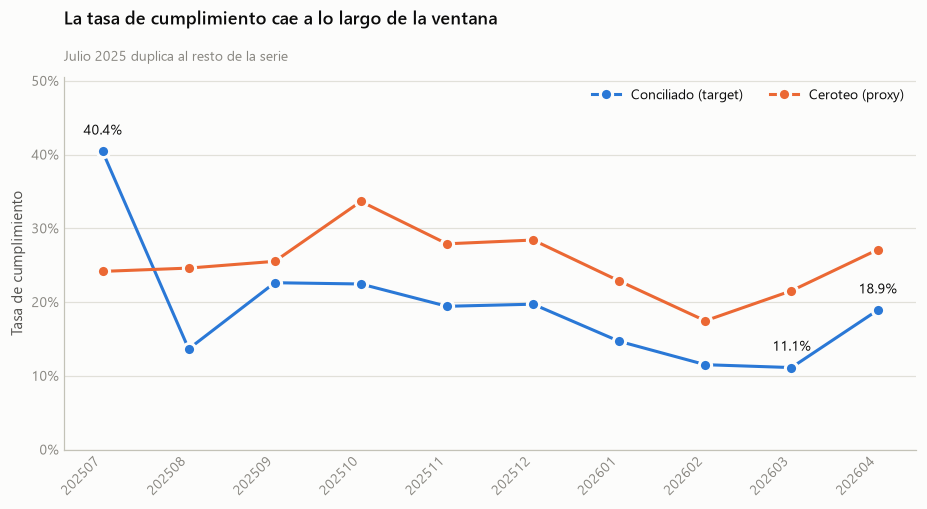

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.4))
x = range(len(mensual))
ax.plot(x, mensual["tasa_conciliado"], color=AZUL, linewidth=2,
        marker="o", markersize=8, markerfacecolor=AZUL,
        markeredgecolor=SUPERFICIE, markeredgewidth=2, label="Conciliado (target)")
ax.plot(x, mensual["tasa_ceroteo"], color=NARANJA, linewidth=2,
        marker="o", markersize=8, markerfacecolor=NARANJA,
        markeredgecolor=SUPERFICIE, markeredgewidth=2, label="Ceroteo (proxy)")

limpiar(ax)
ax.set_xticks(list(x))
ax.set_xticklabels(mensual["mes"], rotation=45, ha="right")
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax.set_ylabel("Tasa de cumplimiento")
ax.set_ylim(0, max(mensual["tasa_ceroteo"].max(), mensual["tasa_conciliado"].max()) * 1.25)
titulos(ax, "La tasa de cumplimiento cae a lo largo de la ventana",
        "Julio 2025 duplica al resto de la serie")
ax.legend(loc="upper right", ncols=2)

# Etiqueta directa selectiva: solo los extremos del target
for i in (0, int(mensual["tasa_conciliado"].idxmin()), len(mensual) - 1):
    v = mensual["tasa_conciliado"].iloc[i]
    ax.annotate(f"{v:.1%}", (i, v), textcoords="offset points", xytext=(0, 11),
                ha="center", fontsize=9, color=TINTA)

guardar(fig, "01_tasa_cumplimiento_por_mes")
plt.show()

figura -> outputs\figuras\02_cobertura_chatbot_por_mes.png


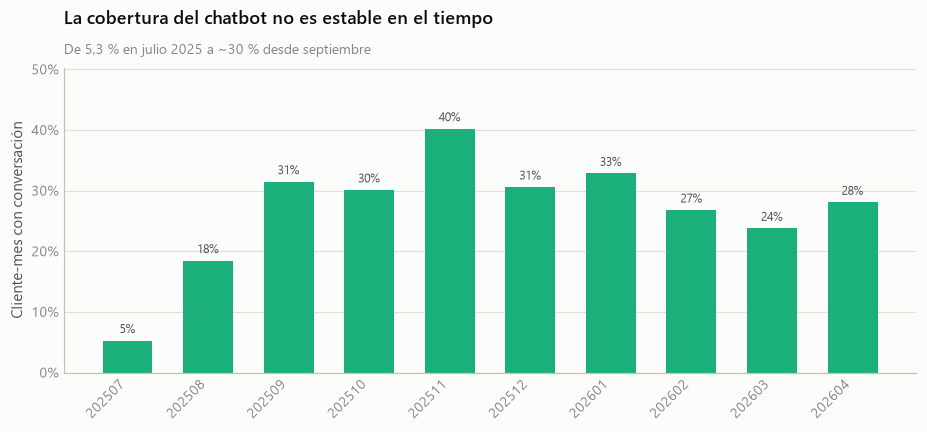

Las dos series van en graficos separados a proposito: superponerlas en un doble eje
inventaria una correlacion que depende solo de como se alineen las dos escalas.


In [12]:
# Grafico aparte, NUNCA un segundo eje sobre el anterior
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.bar(range(len(mensual)), mensual["cobertura_chatbot"], width=0.62, color=AQUA)
limpiar(ax)
ax.set_xticks(range(len(mensual)))
ax.set_xticklabels(mensual["mes"], rotation=45, ha="right")
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax.set_ylabel("Cliente-mes con conversación")
ax.set_ylim(0, mensual["cobertura_chatbot"].max() * 1.25)
titulos(ax, "La cobertura del chatbot no es estable en el tiempo",
        "De 5,3 % en julio 2025 a ~30 % desde septiembre")
for i, v in enumerate(mensual["cobertura_chatbot"]):
    ax.text(i, v + 0.008, f"{v:.0%}", ha="center", va="bottom", fontsize=8, color=TINTA_2)

guardar(fig, "02_cobertura_chatbot_por_mes")
plt.show()

print("Las dos series van en graficos separados a proposito: superponerlas en un doble eje")
print("inventaria una correlacion que depende solo de como se alineen las dos escalas.")

---
## 3 · Variables de cartera

,bucket,n,cumplen,tasa,ic_bajo,ic_alto,err_bajo,err_alto
0,B0,1247,15,0.0120,0.0073,0.0198,0.0047,0.0077
1,B1,7597,2020,0.2659,0.2561,0.2759,0.0098,0.0101
2,B2,8296,1495,0.1802,0.1721,0.1886,0.0081,0.0084
3,B3,1622,232,0.1430,0.1268,0.1609,0.0162,0.0179
4,B4,751,23,0.0306,0.0205,0.0455,0.0101,0.0149
5,B5,682,9,0.0132,0.0070,0.0249,0.0062,0.0117
6,B6,1217,26,0.0214,0.0146,0.0311,0.0067,0.0098
7,B7,62,2,0.0323,0.0089,0.1102,0.0234,0.0779
8,NaN,168,5,0.0298,0.0128,0.0678,0.0170,0.0380


figura -> outputs\figuras\03_tasa_por_bucket.png


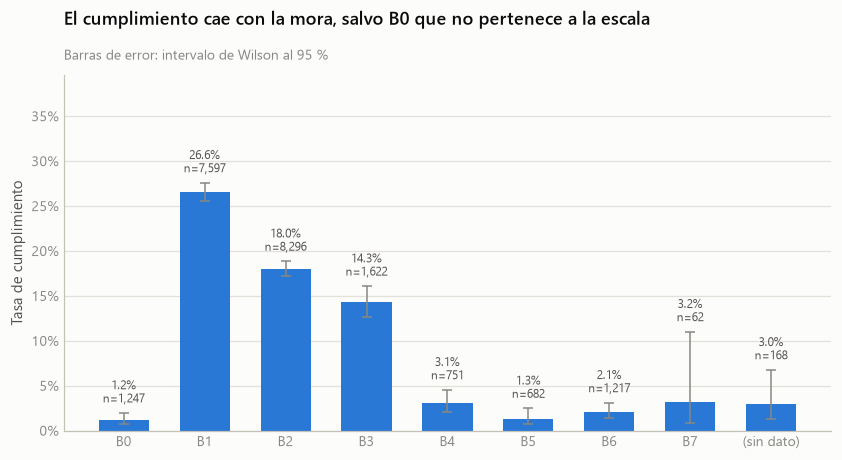

In [13]:
t_bucket = tasa_por(df, "bucket")
display(t_bucket.round(4))
barras_tasa(t_bucket, "bucket",
            "El cumplimiento cae con la mora, salvo B0 que no pertenece a la escala",
            "03_tasa_por_bucket",
            subtitulo="Barras de error: intervalo de Wilson al 95 %")

#### B0 corresponde a otra población

La relación no resulta monótona y conviene no forzarla en el relato. El bucket B0 agrupa clientes
cuyos días de mora inicial son cero, siendo el mínimo, la mediana y el máximo iguales a cero. Es
decir, no tienen deuda vencida y por lo tanto no existe un compromiso de pago que cumplir, lo cual
explica su 1,2 % de cumplimiento y su 96,7 % de ceroteo, ya que se encontraban en cero antes de
comenzar el mes.

Descontando dicho bucket, la escala sí resulta ordenada, pasando de 26,6 % en B1 a 18,0 % en B2,
14,3 % en B3 y entre 1 % y 3 % en los tramos B4 a B7.

In [14]:
sin_mora = df[df["dias_mora_inicial"] == 0]
print(f"Cliente-mes con dias_mora_inicial = 0 : {len(sin_mora):,} ({len(sin_mora)/len(df):.1%})")
print(f"  buckets                            : {sin_mora['bucket'].value_counts(dropna=False).to_dict()}")
print(f"  tasa de cumplimiento_conciliado    : {sin_mora['cumplimiento_conciliado'].mean():.2%}")
print(f"  tasa de cumplimiento_ceroteo       : {sin_mora['cumplimiento_ceroteo'].mean():.2%}")
print(f"  cobertura de chatbot               : {sin_mora['tiene_conversacion'].mean():.2%}")
print()
con_mora = df[df["dias_mora_inicial"] > 0]
print(f"Cliente-mes con mora > 0             : {len(con_mora):,}")
print(f"  tasa de cumplimiento_conciliado    : {con_mora['cumplimiento_conciliado'].mean():.2%}")
print()
print("Casi no reciben chatbot (1.6% frente a ~28%) y casi nunca registran pago conciliado.")
print("Son cuentas al dia dentro del universo gestionado: el modelo de cumplimiento de")
print("compromisos no tiene nada que predecir sobre ellas. Ver la decision en la seccion 6.3.")

Cliente-mes con dias_mora_inicial = 0 : 1,415 (6.5%)
  buckets                            : {'B0': 1247, nan: 168}
  tasa de cumplimiento_conciliado    : 1.41%
  tasa de cumplimiento_ceroteo       : 96.47%
  cobertura de chatbot               : 1.63%

Cliente-mes con mora > 0             : 20,227
  tasa de cumplimiento_conciliado    : 18.82%

Casi no reciben chatbot (1.6% frente a ~28%) y casi nunca registran pago conciliado.
Son cuentas al dia dentro del universo gestionado: el modelo de cumplimiento de
compromisos no tiene nada que predecir sobre ellas. Ver la decision en la seccion 6.3.


,tipo_operacion,n,cumplen,tasa,ic_bajo,ic_alto,err_bajo,err_alto
0,CARTERA,5700,1436,0.2519,0.2408,0.2634,0.0111,0.0114
1,TC,15942,2391,0.1500,0.1445,0.1556,0.0055,0.0056


figura -> outputs\figuras\04_tasa_por_tipo_operacion.png


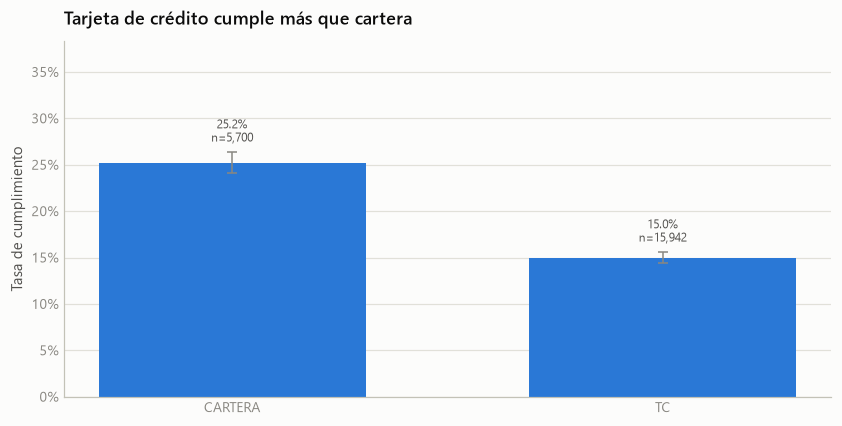

In [15]:
t_op = tasa_por(df, "tipo_operacion")
display(t_op.round(4))
barras_tasa(t_op, "tipo_operacion",
            "Tarjeta de crédito cumple más que cartera",
            "04_tasa_por_tipo_operacion")

,rango_mora,n,cumplen,tasa,ic_bajo,ic_alto,err_bajo,err_alto
0,0,1415,20,0.0141,0.0092,0.0217,0.0050,0.0076
1,1-15,2308,942,0.4081,0.3883,0.4283,0.0199,0.0202
2,16-30,5717,1464,0.2561,0.2449,0.2676,0.0111,0.0115
3,31-45,4974,1003,0.2016,0.1907,0.2130,0.0109,0.0114
4,46-60,3017,282,0.0935,0.0836,0.1044,0.0099,0.0109
5,61-90,1328,53,0.0399,0.0306,0.0518,0.0093,0.0119
6,91-120,854,25,0.0293,0.0199,0.0429,0.0094,0.0136
7,120+,2029,38,0.0187,0.0137,0.0256,0.0051,0.0069


figura -> outputs\figuras\05_tasa_por_rango_mora.png


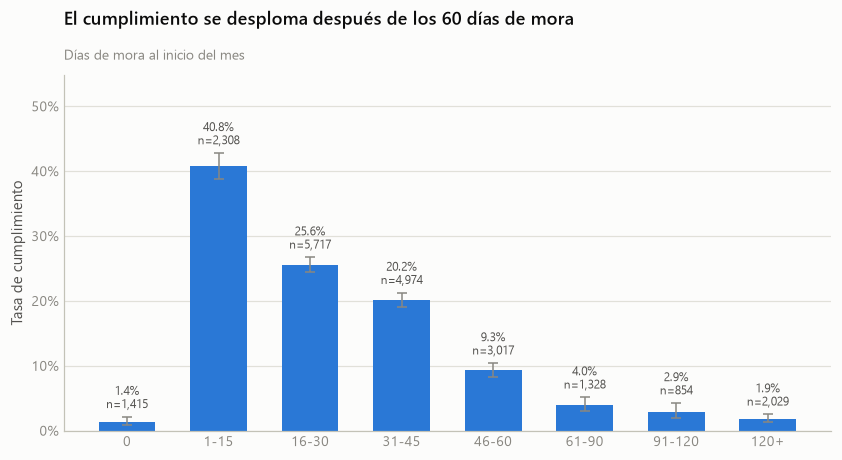

In [16]:
bins = [-1, 0, 15, 30, 45, 60, 90, 120, np.inf]
etiquetas = ["0", "1-15", "16-30", "31-45", "46-60", "61-90", "91-120", "120+"]
df["rango_mora"] = pd.cut(df["dias_mora_inicial"], bins=bins, labels=etiquetas)

t_mora = tasa_por(df, "rango_mora")
display(t_mora.round(4))
barras_tasa(t_mora, "rango_mora",
            "El cumplimiento se desploma después de los 60 días de mora",
            "05_tasa_por_rango_mora",
            subtitulo="Días de mora al inicio del mes")

,meses_consecutivos_mora,n,cumplen,tasa,ic_bajo,ic_alto,err_bajo,err_alto
0,0,1415,20,0.0141,0.0092,0.0217,0.0050,0.0076
1,1,11612,3061,0.2636,0.2557,0.2717,0.0079,0.0081
2,2,6077,579,0.0953,0.0881,0.1029,0.0071,0.0076
3,3,1553,112,0.0721,0.0603,0.0861,0.0118,0.0139
4,4,602,37,0.0615,0.0449,0.0836,0.0165,0.0221
5,5,269,8,0.0297,0.0151,0.0576,0.0146,0.0278
6,6,56,5,0.0893,0.0387,0.1926,0.0505,0.1033
7,7,29,3,0.1034,0.0358,0.2639,0.0676,0.1604
8,8,16,2,0.1250,0.0350,0.3602,0.0900,0.2352
9,9,8,0,0.0000,0.0000,0.3244,0.0000,0.3244


figura -> outputs\figuras\06_tasa_por_racha_mora.png


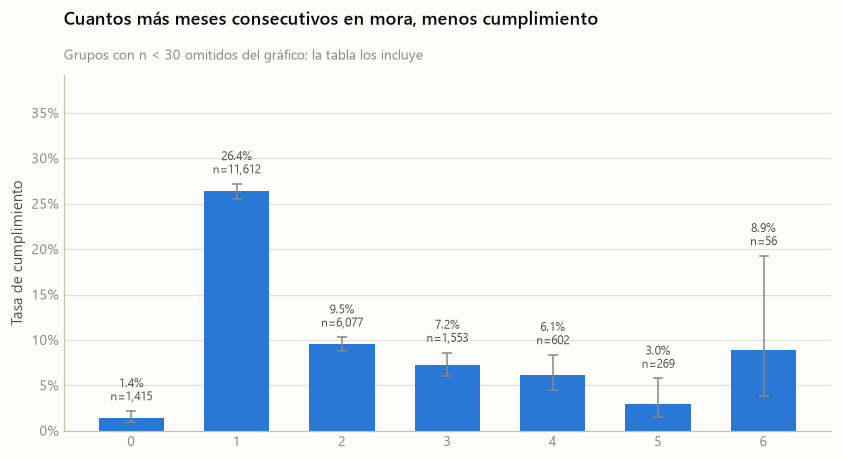

In [17]:
t_racha = tasa_por(df, "meses_consecutivos_mora", min_n=30)
display(tasa_por(df, "meses_consecutivos_mora").round(4))
barras_tasa(t_racha, "meses_consecutivos_mora",
            "Cuantos más meses consecutivos en mora, menos cumplimiento",
            "06_tasa_por_racha_mora",
            subtitulo="Grupos con n < 30 omitidos del gráfico; la tabla los incluye")

---
## 4 · Variables conversacionales

Aquí está la hipótesis del trabajo: que la **secuencia de intenciones** en el chatbot aporta
señal predictiva más allá de los datos de cartera.

,tiene_conversacion,n,cumplen,tasa,ic_bajo,ic_alto,err_bajo,err_alto
0,Sin conversación,15901,2014,0.1267,0.1216,0.1319,0.0051,0.0053
1,Con conversación,5741,1813,0.3158,0.3039,0.3279,0.0119,0.0121


figura -> outputs\figuras\07_tasa_por_contacto_chatbot.png


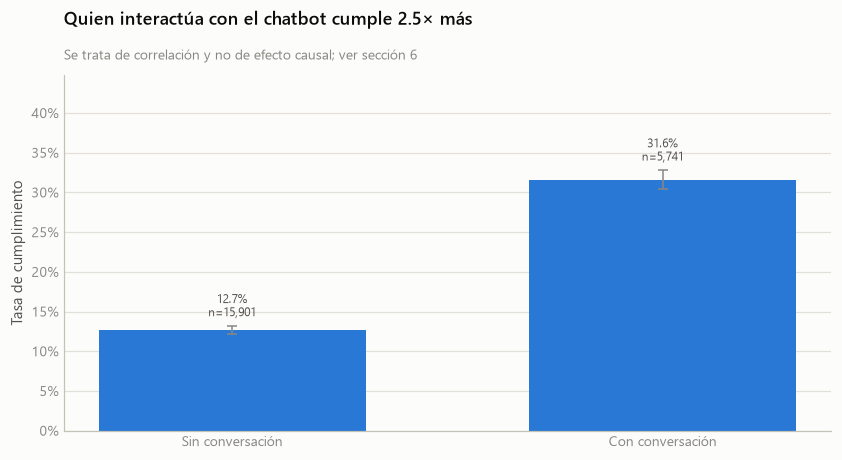

In [18]:
t_conv = tasa_por(df, "tiene_conversacion")
t_conv["tiene_conversacion"] = t_conv["tiene_conversacion"].map({0: "Sin conversación", 1: "Con conversación"})
display(t_conv.round(4))

lift = t_conv.loc[1, "tasa"] / t_conv.loc[0, "tasa"]
barras_tasa(t_conv, "tiene_conversacion",
            f"Quien interactúa con el chatbot cumple {lift:.1f}× más",
            "07_tasa_por_contacto_chatbot",
            subtitulo="Se trata de correlación y no de efecto causal; ver sección 6")

,activo_compromiso,n,cumplen,tasa,ic_bajo,ic_alto,err_bajo,err_alto
0,No activó,18903,3062,0.1620,0.1568,0.1673,0.0052,0.0053
1,Activó compromiso,2739,765,0.2793,0.2628,0.2964,0.0165,0.0171


figura -> outputs\figuras\08_tasa_por_compromiso.png


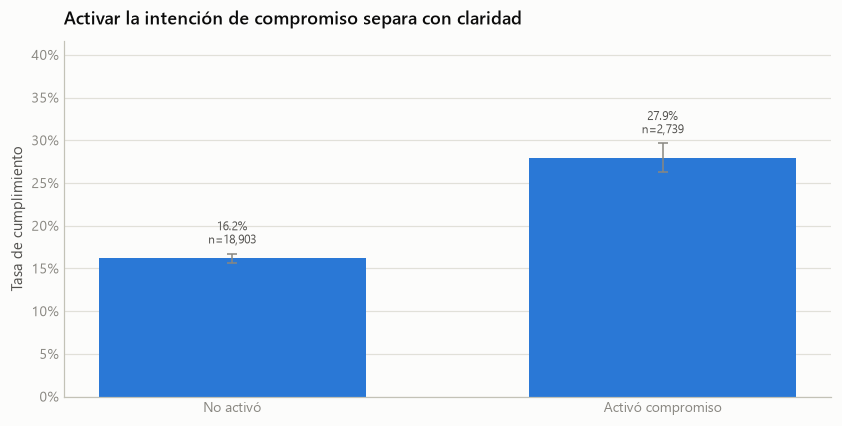

,activo_ya_pague,n,cumplen,tasa,ic_bajo,ic_alto,err_bajo,err_alto
0,No activó,20866,3325,0.1594,0.1544,0.1644,0.0049,0.0050
1,"Activó ""ya pagué""",776,502,0.6469,0.6126,0.6797,0.0343,0.0328


figura -> outputs\figuras\09_tasa_por_ya_pague.png


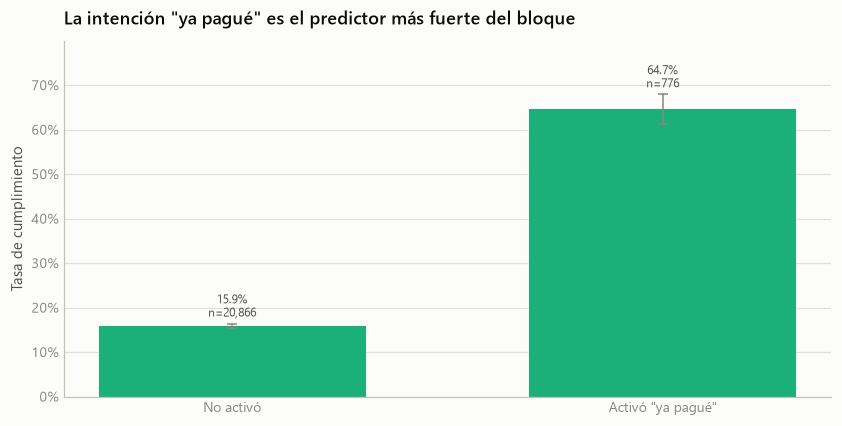

In [19]:
t_comp = tasa_por(df, "activo_compromiso")
t_comp["activo_compromiso"] = t_comp["activo_compromiso"].map({0: "No activó", 1: "Activó compromiso"})
display(t_comp.round(4))
barras_tasa(t_comp, "activo_compromiso",
            "Activar la intención de compromiso separa con claridad",
            "08_tasa_por_compromiso")

t_pag = tasa_por(df, "activo_ya_pague")
t_pag["activo_ya_pague"] = t_pag["activo_ya_pague"].map({0: "No activó", 1: 'Activó "ya pagué"'})
display(t_pag.round(4))
barras_tasa(t_pag, "activo_ya_pague",
            'La intención "ya pagué" es el predictor más fuerte del bloque',
            "09_tasa_por_ya_pague", color=AQUA)

,dias_compromiso,n,cumplen,tasa,ic_bajo,ic_alto,err_bajo,err_alto
0,1,216,117,0.5417,0.4751,0.6068,0.0666,0.0651
1,2,6,0,0.0000,0.0000,0.3903,0.0000,0.3903
2,3,141,74,0.5248,0.4428,0.6055,0.0820,0.0807
3,5,745,219,0.2940,0.2624,0.3277,0.0316,0.0337


figura -> outputs\figuras\10_tasa_por_plazo_compromiso.png


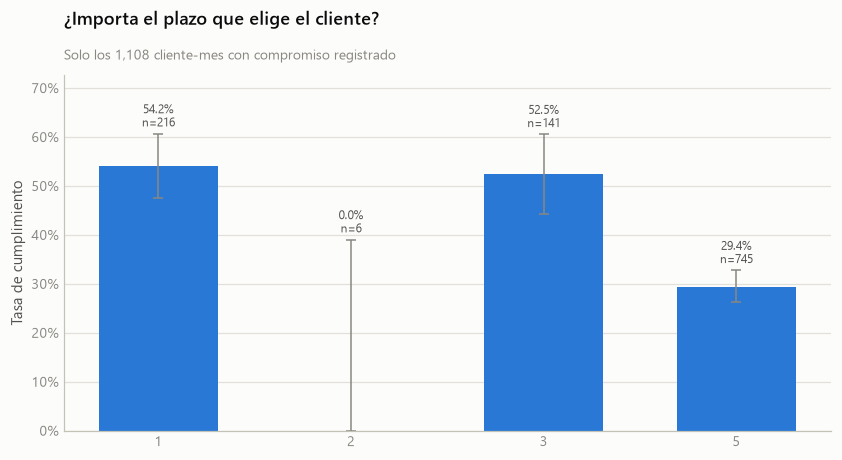

In [20]:
sub = df[df["dias_compromiso"].notna()].copy()
sub["dias_compromiso"] = sub["dias_compromiso"].astype(int)
t_dias = tasa_por(sub, "dias_compromiso")
display(t_dias.round(4))
barras_tasa(t_dias, "dias_compromiso",
            "¿Importa el plazo que elige el cliente?",
            "10_tasa_por_plazo_compromiso",
            subtitulo=f"Solo los {len(sub):,} cliente-mes con compromiso registrado")

,rango_intenciones,n,cumplen,tasa,ic_bajo,ic_alto,err_bajo,err_alto
0,1,1469,397,0.2703,0.2482,0.2935,0.0221,0.0233
1,2,1412,456,0.3229,0.2991,0.3478,0.0239,0.0248
2,3,780,272,0.3487,0.3161,0.3828,0.0326,0.0341
3,4-5,929,321,0.3455,0.3156,0.3767,0.0299,0.0312
4,6-10,820,263,0.3207,0.2897,0.3535,0.0310,0.0327
5,11+,331,104,0.3142,0.2666,0.3661,0.0476,0.0519


figura -> outputs\figuras\11_tasa_por_volumen_intenciones.png


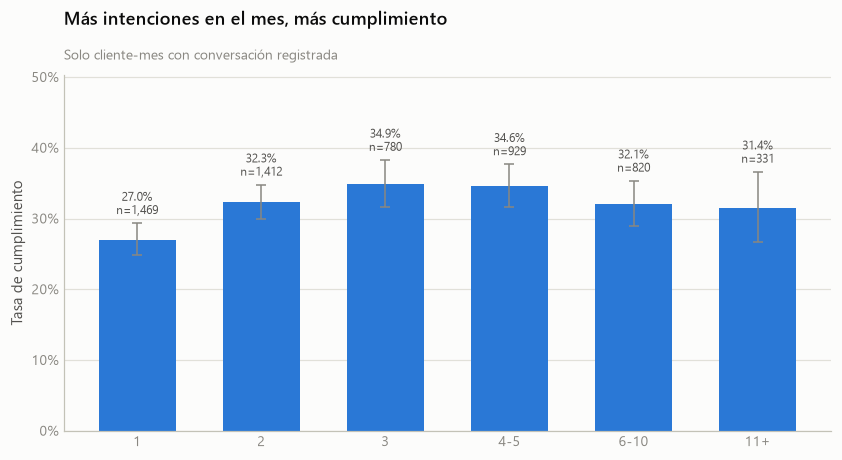

In [21]:
sub = df[df["tiene_conversacion"] == 1].copy()
sub["rango_intenciones"] = pd.cut(sub["total_intenciones"], bins=[0, 1, 2, 3, 5, 10, np.inf],
                                  labels=["1", "2", "3", "4-5", "6-10", "11+"])
t_int = tasa_por(sub, "rango_intenciones")
display(t_int.round(4))
barras_tasa(t_int, "rango_intenciones",
            "Más intenciones en el mes, más cumplimiento",
            "11_tasa_por_volumen_intenciones",
            subtitulo="Solo cliente-mes con conversación registrada")

,hora_primera_interaccion,n,cumplen,tasa,ic_bajo,ic_alto,err_bajo,err_alto
0,0.0,7,0,0.0000,0.0000,0.3543,0.0000,0.3543
1,1.0,6,0,0.0000,0.0000,0.3903,0.0000,0.3903
2,2.0,7,2,0.2857,0.0822,0.6411,0.2035,0.3554
3,3.0,2,1,0.5000,0.0945,0.9055,0.4055,0.4055
4,4.0,2,0,0.0000,0.0000,0.6576,0.0000,0.6576
5,5.0,10,2,0.2000,0.0567,0.5098,0.1433,0.3098
6,6.0,32,6,0.1875,0.0889,0.3531,0.0986,0.1656
7,7.0,42,8,0.1905,0.0998,0.3330,0.0907,0.1425
8,8.0,61,15,0.2459,0.1551,0.3668,0.0908,0.1209
9,9.0,73,15,0.2055,0.1287,0.3117,0.0768,0.1063


figura -> outputs\figuras\12_tasa_por_hora.png


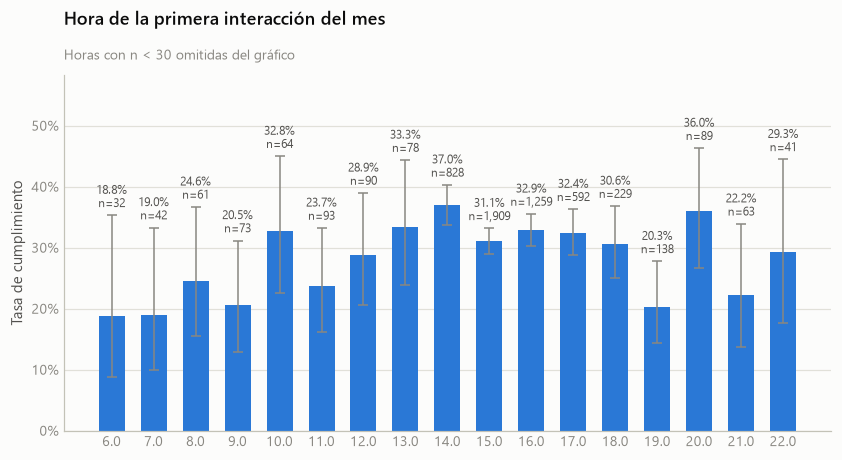

,dia_semana_primera_interaccion,n,cumplen,tasa,ic_bajo,ic_alto,err_bajo,err_alto
0,Lunes,981,355,0.3619,0.3324,0.3924,0.0295,0.0306
1,Martes,1207,401,0.3322,0.3062,0.3593,0.0260,0.0271
2,Miércoles,1344,336,0.2500,0.2276,0.2738,0.0224,0.0238
3,Jueves,1313,463,0.3526,0.3272,0.3789,0.0254,0.0262
4,Viernes,809,237,0.2930,0.2626,0.3252,0.0303,0.0323
5,Sábado,64,17,0.2656,0.1730,0.3848,0.0927,0.1192
6,Domingo,23,4,0.1739,0.0698,0.3714,0.1041,0.1975


figura -> outputs\figuras\13_tasa_por_dia_semana.png


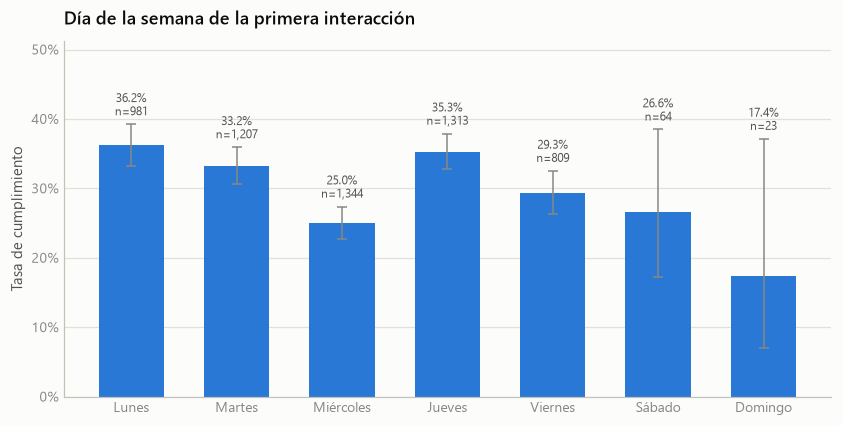

In [22]:
sub = df[df["tiene_conversacion"] == 1].copy()
t_hora = tasa_por(sub, "hora_primera_interaccion", min_n=30)
display(tasa_por(sub, "hora_primera_interaccion").round(4))
barras_tasa(t_hora, "hora_primera_interaccion",
            "Hora de la primera interacción del mes",
            "12_tasa_por_hora", subtitulo="Horas con n < 30 omitidas del gráfico")

DIAS = {0: "Lunes", 1: "Martes", 2: "Miércoles", 3: "Jueves", 4: "Viernes", 5: "Sábado", 6: "Domingo"}
t_dia = tasa_por(sub, "dia_semana_primera_interaccion")
t_dia["dia_semana_primera_interaccion"] = t_dia["dia_semana_primera_interaccion"].map(DIAS)
display(t_dia.round(4))
barras_tasa(t_dia, "dia_semana_primera_interaccion",
            "Día de la semana de la primera interacción",
            "13_tasa_por_dia_semana")

,ultima_intencion_antes_compromiso,n,cumplen,tasa,ic_bajo,ic_alto,err_bajo,err_alto
0,SIN_PREVIA,1419,447,0.3150,0.2914,0.3397,0.0236,0.0246
12,formas_pago,914,211,0.2309,0.2047,0.2593,0.0262,0.0284
4,ahora_no_contact,122,26,0.2131,0.1498,0.2940,0.0633,0.0808
5,banca_virtual,70,13,0.1857,0.1119,0.2923,0.0738,0.1065
14,hablar_asesor,46,19,0.4130,0.2829,0.5566,0.1302,0.1436
7,default fallback intent,39,9,0.2308,0.1265,0.3834,0.1043,0.1526
3,agencia_cercana,30,3,0.1000,0.0346,0.2562,0.0654,0.1562
8,default welcome intent,24,7,0.2917,0.1491,0.4917,0.1425,0.2000
10,detalle_saldo,22,8,0.3636,0.1973,0.5705,0.1663,0.2069
24,ya_pague,17,7,0.4118,0.2161,0.6399,0.1957,0.2282


figura -> outputs\figuras\14_tasa_por_intencion_previa.png


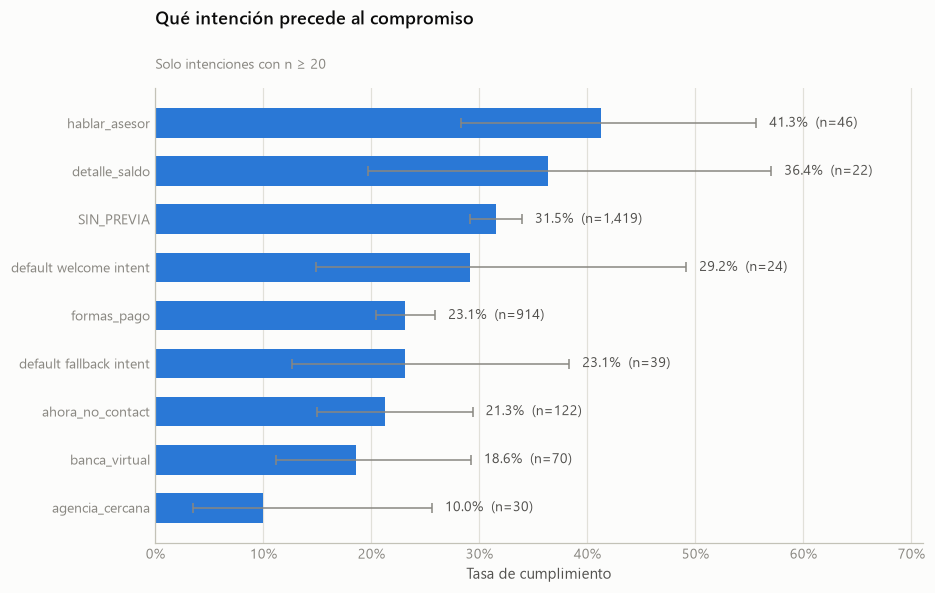

In [23]:
sub = df[df["ultima_intencion_antes_compromiso"].isin(["NO_APLICA", "SIN_DATOS"]) == False].copy()
t_prev = tasa_por(sub, "ultima_intencion_antes_compromiso", min_n=20)
display(tasa_por(sub, "ultima_intencion_antes_compromiso").sort_values("n", ascending=False).round(4))
if len(t_prev):
    barras_tasa(t_prev, "ultima_intencion_antes_compromiso",
                "Qué intención precede al compromiso",
                "14_tasa_por_intencion_previa", horizontal=True, ordenar=True,
                subtitulo="Solo intenciones con n ≥ 20")
else:
    print("Sin categorias con n >= 20")

---
## 5 · Correlaciones e información mutua

figura -> outputs\figuras\15_matriz_correlacion.png


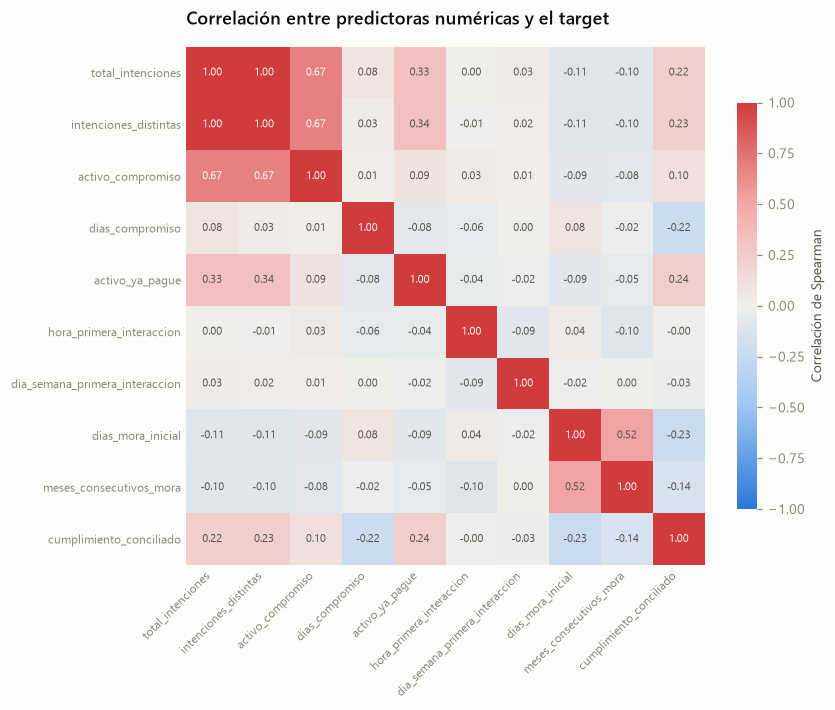


Correlacion de cada predictora con el target:
activo_ya_pague                   0.2376
intenciones_distintas             0.2258
total_intenciones                 0.2204
activo_compromiso                 0.1022
hora_primera_interaccion         -0.0027
dia_semana_primera_interaccion   -0.0302
meses_consecutivos_mora          -0.1411
dias_compromiso                  -0.2242
dias_mora_inicial                -0.2296


In [24]:
num = df[[c for c in PREDICTORAS if pd.api.types.is_numeric_dtype(df[c])] + [TARGET]]
corr = num.corr(method="spearman")

fig, ax = plt.subplots(figsize=(7.6, 6.4))
# Divergente azul<->rojo con gris neutro en el cero (nunca arcoiris)
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "div", ["#2a78d6", "#9ec5f4", "#f0efec", "#f3a9a8", "#d03b3b"])
im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.columns, fontsize=8)
ax.grid(False)
for lado in ("top", "right", "bottom", "left"):
    ax.spines[lado].set_visible(False)
ax.tick_params(length=0)

for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                color=SUPERFICIE if abs(v) > 0.55 else TINTA_2)

cb = fig.colorbar(im, ax=ax, shrink=0.75)
cb.outline.set_visible(False)
cb.set_label("Correlación de Spearman", color=TINTA_2, fontsize=9)
titulos(ax, "Correlación entre predictoras numéricas y el target")
guardar(fig, "15_matriz_correlacion")
plt.show()

print("\nCorrelacion de cada predictora con el target:")
print(corr[TARGET].drop(TARGET).sort_values(ascending=False).round(4).to_string())

,informacion_mutua
dias_mora_inicial,0.07927
meses_consecutivos_mora,0.03759
dia_semana_primera_interaccion,0.02741
ultima_intencion_antes_compromiso,0.02371
intenciones_distintas,0.02343
total_intenciones,0.02281
hora_primera_interaccion,0.02240
activo_ya_pague,0.01864
dias_compromiso,0.00585
activo_compromiso,0.00333


figura -> outputs\figuras\16_informacion_mutua.png


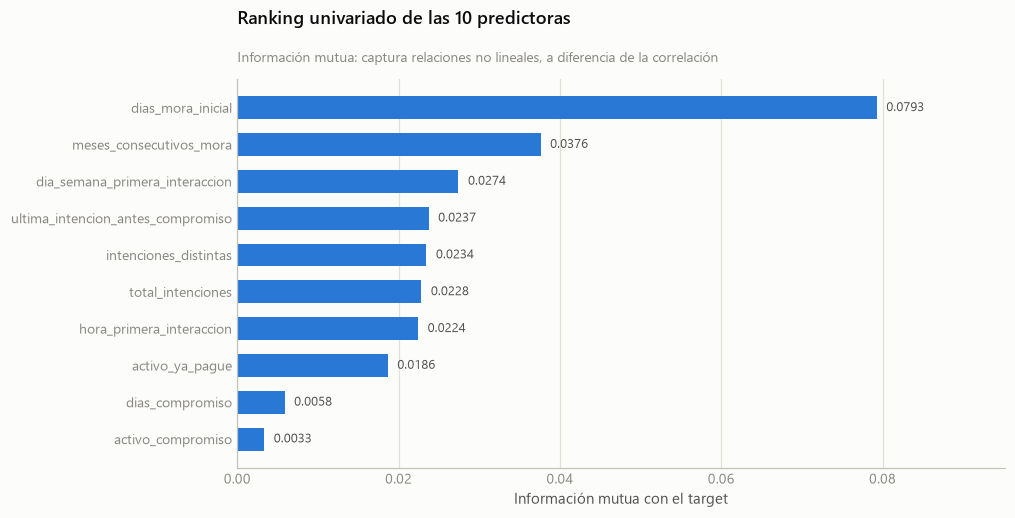

In [25]:
from sklearn.feature_selection import mutual_info_classif

X = df[PREDICTORAS].copy()
for c in X.columns:
    if not pd.api.types.is_numeric_dtype(X[c]):
        X[c] = X[c].astype("category").cat.codes
X = X.fillna(-1)

mi = pd.Series(
    mutual_info_classif(X, df[TARGET], discrete_features="auto", random_state=42),
    index=PREDICTORAS).sort_values()
display(mi.sort_values(ascending=False).round(5).to_frame("informacion_mutua"))

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(mi.index, mi.values, height=0.62, color=AZUL)
limpiar(ax, eje_x=False)
ax.set_xlabel("Información mutua con el target")
for y, v in enumerate(mi.values):
    ax.text(v + mi.max() * 0.015, y, f"{v:.4f}", va="center", fontsize=8.5, color=TINTA_2)
ax.set_xlim(0, mi.max() * 1.20)
titulos(ax, "Ranking univariado de las 10 predictoras",
        "Información mutua: captura relaciones no lineales, a diferencia de la correlación")
guardar(fig, "16_informacion_mutua")
plt.show()

---
## 6 · Sesgo de selección

El hallazgo de la sección anterior, según el cual quien conversa con el chatbot cumple bastante más,
constituye el resultado más llamativo del análisis y también el más fácil de malinterpretar.

Cabe aclarar que el chatbot no contacta a una muestra aleatoria. Registra conversación únicamente
cuando el cliente contesta, y quien contesta probablemente ya tenía mayor intención de pagar. Es
decir, parte del efecto observado corresponde al canal y parte corresponde a quién alcanza el canal,
y con estos datos ambas cosas no pueden separarse.

Sin embargo, sí resulta posible comprobar si el efecto sobrevive al controlar por riesgo. Si dentro
de cada bucket de mora la brecha persiste, entonces no se explica únicamente porque el chatbot
alcance a los clientes menos riesgosos.

,sin_conversacion,con_conversacion,n_sin,n_con,brecha_pp
bucket,,,,,
B0,0.0081,0.2500,1227,20,24.1850
B1,0.1973,0.3830,4790,2807,18.5685
B2,0.1476,0.2753,6178,2118,12.7639
B3,0.0905,0.2897,1194,428,19.9267
B4,0.0235,0.0584,597,154,3.4991
B5,0.0082,0.0571,612,70,4.8973
B6,0.0138,0.0853,1088,129,7.1485
B7,0.0000,0.1667,50,12,16.6667


figura -> outputs\figuras\17_brecha_controlada_por_bucket.png


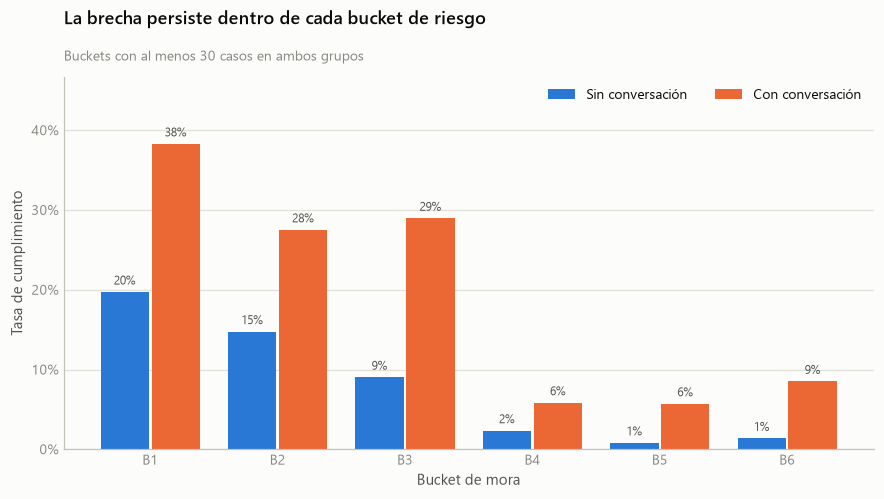


Brecha promedio dentro de bucket: 11.1 puntos porcentuales
La brecha no desaparece al controlar por riesgo, pero el diseno observacional
no permite atribuirla causalmente al chatbot. En la memoria debe reportarse
como asociacion y no como efecto de la intervencion.


In [26]:
control = (df.groupby(["bucket", "tiene_conversacion"])[TARGET]
             .agg(n="size", tasa="mean").reset_index())
pivote_tasa = control.pivot(index="bucket", columns="tiene_conversacion", values="tasa")
pivote_n = control.pivot(index="bucket", columns="tiene_conversacion", values="n")
pivote_tasa.columns = ["sin_conversacion", "con_conversacion"]
pivote_n.columns = ["n_sin", "n_con"]
comparacion = pivote_tasa.join(pivote_n)
comparacion["brecha_pp"] = (comparacion["con_conversacion"] - comparacion["sin_conversacion"]) * 100
display(comparacion.round(4))

validos = comparacion[(comparacion["n_sin"] >= 30) & (comparacion["n_con"] >= 30)]
fig, ax = plt.subplots(figsize=(9.5, 4.4))
x = np.arange(len(validos))
ancho = 0.38
ax.bar(x - ancho/2 - 0.01, validos["sin_conversacion"], ancho, color=AZUL, label="Sin conversación")
ax.bar(x + ancho/2 + 0.01, validos["con_conversacion"], ancho, color=NARANJA, label="Con conversación")
limpiar(ax)
ax.set_xticks(x)
ax.set_xticklabels(validos.index)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax.set_ylabel("Tasa de cumplimiento")
ax.set_xlabel("Bucket de mora")
titulos(ax, "La brecha persiste dentro de cada bucket de riesgo",
        "Buckets con al menos 30 casos en ambos grupos")
ax.legend(loc="upper right", ncols=2)
for xi, (a, b) in enumerate(zip(validos["sin_conversacion"], validos["con_conversacion"])):
    ax.text(xi - ancho/2 - 0.01, a + 0.006, f"{a:.0%}", ha="center", va="bottom", fontsize=8, color=TINTA_2)
    ax.text(xi + ancho/2 + 0.01, b + 0.006, f"{b:.0%}", ha="center", va="bottom", fontsize=8, color=TINTA_2)
ax.set_ylim(0, max(validos["con_conversacion"].max(), validos["sin_conversacion"].max()) * 1.22)
guardar(fig, "17_brecha_controlada_por_bucket")
plt.show()

print(f"\nBrecha promedio dentro de bucket: {validos['brecha_pp'].mean():.1f} puntos porcentuales")
print("La brecha no desaparece al controlar por riesgo, pero el diseno observacional")
print("no permite atribuirla causalmente al chatbot. En la memoria debe reportarse")
print("como asociacion y no como efecto de la intervencion.")

### 6.1 · Fuga de información: verificación

El dataset se construyó excluyendo `dias_mora_cierre`, `fecha_pago`, `monto_recuperado` y
`fecha_cierre_mes` por ser posteriores al resultado del mes. Esta celda confirma que ninguna
columna sobreviviente tenga una relación sospechosamente perfecta con el target, que constituye el síntoma
clásico de una fuga que se coló.

In [27]:
sospechosas = []
for c in PREDICTORAS + CONTEXTO:
    if df[c].nunique() > 60:
        continue
    g = df.groupby(c, dropna=False)[TARGET].agg(["size", "mean"])
    g = g[g["size"] >= 20]
    if len(g) and (g["mean"].max() > 0.97 or g["mean"].min() < 0.01):
        sospechosas.append((c, round(g["mean"].min(), 4), round(g["mean"].max(), 4)))

if sospechosas:
    print("Revisar estas variables: algun grupo predice el target casi perfectamente")
    for s in sospechosas:
        print("  ", s)
else:
    print("Sin señales de fuga: ninguna categoria con n>=20 predice el target de forma casi")
    print("perfecta. La tasa mas extrema por grupo se mantiene dentro de un rango razonable.")

print(f"\nRango de tasas por bucket        : {t_bucket['tasa'].min():.1%} - {t_bucket['tasa'].max():.1%}")
print(f"Rango de tasas por rango de mora : {t_mora['tasa'].min():.1%} - {t_mora['tasa'].max():.1%}")

Revisar estas variables: algun grupo predice el target casi perfectamente
   ('lote_control', np.float64(0.0), np.float64(0.5146))

Rango de tasas por bucket        : 1.2% - 26.6%
Rango de tasas por rango de mora : 1.4% - 40.8%


### 6.2 · Celdas con el target incompleto

La verificación anterior marcó `lote_control`. Al abrirlo aparece algo que **no es una fuga sino
un problema de completitud del target**, y es el hallazgo más delicado del EDA.

Cada lote cubre uno o dos meses: es un identificador de campaña, prácticamente un proxy del mes.
Por ende no debe entrar como predictor, dado que con partición temporal los lotes del período de
prueba son categorías nunca vistas.

El análisis hay que hacerlo a nivel **mes × lote**, no por lote: un mismo lote puede estar bien
conciliado en un mes y no en el siguiente, y agregarlo esconde el problema.

In [28]:
celdas = (df.groupby(["mes", "lote_control"])
            .agg(n=(TARGET, "size"), positivos=(TARGET, "sum"),
                 conciliado=(TARGET, "mean"), ceroteo=(PROXY, "mean"),
                 mora=("dias_mora_inicial", "mean"))
            .reset_index())
display(celdas.sort_values("conciliado").head(12).round(3))
print(f"Celdas mes x lote: {len(celdas)} | lotes distintos: {df['lote_control'].nunique()}")

,mes,lote_control,n,positivos,conciliado,ceroteo,mora
25,202603,53_ad,1205,0,0.000,0.108,125.152
30,202604,57,572,0,0.000,0.124,49.439
8,202510,39,592,19,0.032,0.321,23.162
11,202511,42,507,17,0.034,0.162,56.132
17,202601,48,731,27,0.037,0.168,54.503
24,202603,53,1282,53,0.041,0.163,62.027
23,202602,53_ad,1188,62,0.052,0.066,132.997
14,202512,44,831,56,0.067,0.219,44.910
5,202509,36,666,45,0.068,0.210,42.051
28,202604,55,1180,93,0.079,0.252,47.421


Celdas mes x lote: 31 | lotes distintos: 21


#### El criterio: un cero que no puede ser azar

Una celda con conciliación exactamente cero puede ser real (un segmento muy malo) o puede ser un
target que no llegó. Para distinguirlas no sirve el relato, sirve la probabilidad: **¿qué tan
verosímil es observar cero pagos en `n` registros, si la tasa fuese la de una población
comparable?**

La referencia se toma de cliente-mes con **mora parecida (±20 %)** fuera de la propia celda, y se
evalúa con un test binomial exacto. Si la probabilidad es absurdamente baja, el cero no es
comportamiento: es un dato que falta.

In [29]:
from scipy.stats import binomtest

def celdas_sospechosas(df, alpha=1e-6, min_n=50, min_ref=100):
    """Celdas mes x lote con cero positivos donde el cero es estadisticamente inverosimil."""
    base = (df.groupby(["mes", "lote_control"])
              .agg(n=(TARGET, "size"), positivos=(TARGET, "sum"),
                   ceroteo=(PROXY, "mean"), mora=("dias_mora_inicial", "mean"))
              .reset_index())
    base = base[(base["n"] >= min_n) & (base["positivos"] == 0)]

    filas = []
    for _, r in base.iterrows():
        fuera = ~((df["mes"] == r["mes"]) & (df["lote_control"] == r["lote_control"]))
        ref = df[fuera & df["dias_mora_inicial"].between(r["mora"] * 0.8, r["mora"] * 1.2)]
        if len(ref) < min_ref:
            continue
        p_ref = ref[TARGET].mean()
        if p_ref <= 0:
            continue
        p_valor = binomtest(0, int(r["n"]), p_ref, alternative="less").pvalue
        filas.append({
            "mes": r["mes"], "lote_control": r["lote_control"], "n": int(r["n"]),
            "ceroteo": r["ceroteo"], "mora_media": r["mora"],
            "tasa_referencia": p_ref, "n_referencia": len(ref), "p_valor": p_valor,
            "inverosimil": p_valor < alpha,
        })
    return pd.DataFrame(filas)


sospecha = celdas_sospechosas(df)
display(sospecha.round(6))

censuradas = [(r["mes"], r["lote_control"]) for _, r in sospecha.iterrows() if r["inverosimil"]]
print(f"Celdas con cero estadisticamente inverosimil: {censuradas}")
for mes, lote in censuradas:
    s = df[(df["mes"] == mes) & (df["lote_control"] == lote)]
    clientes = set(s["id_anonimo"])
    historia = df[df["id_anonimo"].isin(clientes) & ~((df["mes"] == mes) & (df["lote_control"] == lote))]
    print(f"\n{mes} / lote {lote}: {len(s):,} registros, 0 conciliados")
    print(f"   llegaron a mora cero    : {int(s[PROXY].sum())} ({s[PROXY].mean():.1%})")
    print(f"   activaron compromiso    : {s['activo_compromiso'].mean():.1%}")
    if len(historia):
        print(f"   esos clientes en otros meses ({len(historia):,} registros): "
              f"cumplen {historia[TARGET].mean():.1%}")

,mes,lote_control,n,ceroteo,mora_media,tasa_referencia,n_referencia,p_valor,inverosimil
0,202603,53_ad,1205,0.107884,125.151867,0.022965,958,0.0,True
1,202604,57,572,0.124126,49.438811,0.108276,4978,0.0,True


Celdas con cero estadisticamente inverosimil: [('202603', '53_ad'), ('202604', '57')]

202603 / lote 53_ad: 1,205 registros, 0 conciliados
   llegaron a mora cero    : 130 (10.8%)
   activaron compromiso    : 0.4%
   esos clientes en otros meses (1,474 registros): cumplen 6.4%

202604 / lote 57: 572 registros, 0 conciliados
   llegaron a mora cero    : 71 (12.4%)
   activaron compromiso    : 16.8%
   esos clientes en otros meses (175 registros): cumplen 22.3%


La evidencia disponible sostiene dos afirmaciones y descarta una tercera.

- Estos ceros no corresponden al comportamiento de los clientes. Con las tasas de referencia
  observadas, la probabilidad de no registrar ni un solo pago es del orden de diez elevado a menos
  veintinueve, de modo que un cero exacto sobre 1.212 y 575 registros no ocurre por azar.
- El indicador es internamente consistente, dado que en todo el dataset los registros con
  `cumplimiento_conciliado = 0` no presentan `fecha_pago` ni `monto_recuperado`. Es decir, no hay
  pagos que el indicador esté ignorando, sino que falta el registro completo.

En cambio, la evidencia no sostiene un mecanismo concreto. Se probó la hipótesis de que se tratara
de lotes cargados tarde, con poca ventana de gestión antes del cierre, y no se sostiene, ya que los
días disponibles entre la carga y el fin de mes correlacionan de forma negativa con el cumplimiento,
en sentido contrario al esperado, y una de las dos celdas disponía del mes completo. Por ende, la
ventana estaba confundida con la composición de mora de cada lote.

En conclusión, el target de esas dos celdas falta por una causa que los datos no permiten
identificar. Puede tratarse de conciliación pendiente, de un canal de pago distinto o de un proceso
que no se ejecutó, lo cual constituye una consulta para la empresa y no un problema del dataset.

### 6.3 · Población de modelado

Dos exclusiones, cada una detrás de su bandera para que la decisión quede explícita y sea
reversible:

| Exclusión | Motivo | Estado |
|---|---|---|
| Celdas mes × lote con cero inverosímil | Target ausente: negativos que en realidad son desconocidos | **Pendiente de confirmar con Amapola** |
| `dias_mora_inicial = 0` | No hay compromiso de pago que cumplir; el modelo no tiene nada que predecir | Decisión metodológica |

In [30]:
EXCLUIR_TARGET_AUSENTE = True    # revertir si Amapola confirma que el cero es real
EXCLUIR_SIN_MORA_INICIAL = True  # revertir si el negocio considera que son parte del universo

df_modelado = df.copy()
if EXCLUIR_TARGET_AUSENTE and censuradas:
    antes = len(df_modelado)
    clave = list(zip(df_modelado["mes"], df_modelado["lote_control"]))
    df_modelado = df_modelado[[k not in censuradas for k in clave]]
    print(f"  -> excluidos {antes - len(df_modelado):,} cliente-mes por target ausente "
          f"en {censuradas}")

if EXCLUIR_SIN_MORA_INICIAL:
    antes = len(df_modelado)
    df_modelado = df_modelado[df_modelado["dias_mora_inicial"] > 0]
    print(f"  -> excluidos {antes - len(df_modelado):,} cliente-mes sin mora al inicio")

df_modelado = df_modelado.copy()
r = (len(df_modelado) - df_modelado[TARGET].sum()) / df_modelado[TARGET].sum()
print(f"""
Dataset completo : {len(df):,} cliente-mes | positivos {df[TARGET].mean():.2%}
Dataset modelado : {len(df_modelado):,} cliente-mes | positivos {df_modelado[TARGET].mean():.2%}
                   clientes {df_modelado['id_anonimo'].nunique():,}
scale_pos_weight : {r:.3f}   (antes {(len(df)-df[TARGET].sum())/df[TARGET].sum():.3f})
cobertura chatbot: {df_modelado['tiene_conversacion'].mean():.1%}   (antes {df['tiene_conversacion'].mean():.1%})""")

ruta = DIR_OUTPUTS / "dataset_modelado_v1.csv"
df_modelado.to_csv(ruta, index=False, encoding="utf-8")
print(f"\nExportado: {ruta.relative_to(RAIZ)}")

print("\nTasa de cumplimiento por mes tras las exclusiones:")
print(df_modelado.groupby("mes")[TARGET].agg(["size", "sum", "mean"]).round(4).to_string())

  -> excluidos 1,777 cliente-mes por target ausente en [('202603', '53_ad'), ('202604', '57')]
  -> excluidos 1,285 cliente-mes sin mora al inicio

Dataset completo : 21,642 cliente-mes | positivos 17.68%
Dataset modelado : 18,580 cliente-mes | positivos 20.49%
                   clientes 9,906
scale_pos_weight : 3.880   (antes 4.655)
cobertura chatbot: 29.6%   (antes 26.5%)



Exportado: outputs\dataset_modelado_v1.csv



Tasa de cumplimiento por mes tras las exclusiones:
        size  sum    mean
mes                      
202507  1464  600  0.4098
202508  1909  287  0.1503
202509  1787  425  0.2378
202510  1296  328  0.2531
202511  1618  326  0.2015
202512  1430  303  0.2119
202601  1574  244  0.1550
202602  3128  375  0.1199
202603  2605  438  0.1681
202604  1769  481  0.2719


---
## 7 · Conclusiones para el modelado

In [31]:
print("=" * 70)
print("RESUMEN PARA LA FASE 3")
print("=" * 70)
r_mod = (len(df_modelado) - df_modelado[TARGET].sum()) / df_modelado[TARGET].sum()
print(f"""
Dataset completo : {len(df):,} cliente-mes | {df['id_anonimo'].nunique():,} clientes | 10 meses
Dataset modelado : {len(df_modelado):,} cliente-mes tras excluir lotes sin conciliar
Target           : cumplimiento_conciliado, {df_modelado[TARGET].mean():.2%} de positivos
Desbalance       : {r_mod:.2f} : 1  ->  scale_pos_weight = {r_mod:.3f}

Exclusiones      : celdas mes x lote {censuradas} por target ausente, y los cliente-mes
                   con dias_mora_inicial = 0 (sin compromiso que cumplir).

PENDIENTE        : preguntar a Amapola por que esas dos celdas no tienen ningun pago
                   conciliado. Los datos descartan que sea comportamiento (P ~ 1e-29)
                   pero no identifican la causa. Si el cero resulta real, revertir
                   EXCLUIR_TARGET_AUSENTE.

Particion        : split TEMPORAL, no aleatorio. La tasa de cumplimiento cae de 40% a 11%
                   y la cobertura del chatbot sube de 5% a 30% a lo largo de la ventana.
                   Un split aleatorio filtraria el futuro y sobreestimaria el desempeno.
                   Sugerido: entrenar 202507-202601, validar 202602-202604. Con la celda
                   censurada ya excluida, abril 2026 vuelve a ser utilizable.

No usar de feature: lote_control (cada lote cubre 1-2 meses, es un proxy del mes; con split
                   temporal los lotes de prueba son categorias nunca vistas) ni mes.

Agrupamiento     : un mismo cliente aparece en varios meses. La validacion cruzada debe ser
                   StratifiedGroupKFold agrupando por id_anonimo, para que el mismo cliente
                   no quede a la vez en train y en test.

Nulos            : no imputar. dias_compromiso y hora/dia_semana son nulos estructurales
                   y XGBoost aprende la direccion del faltante por si mismo.

Categoricas      : bucket, tipo_operacion, lote_control y ultima_intencion_antes_compromiso.
                   Usar enable_categorical=True de XGBoost, o one-hot si se prefiere
                   trazabilidad en la memoria.

Metricas         : PR-AUC como metrica principal (el desbalance hace que ROC-AUC se vea
                   optimista), mas recall y precision en el umbral operativo. Reportar
                   calibracion: el valor del modelo esta en priorizar gestion, y para eso
                   la probabilidad tiene que significar algo.

Comparacion      : entrenar tambien contra cumplimiento_ceroteo para cuantificar cuanto
                   cambia el modelo al usar el proxy interno (kappa observado: bajo).
""")

RESUMEN PARA LA FASE 3

Dataset completo : 21,642 cliente-mes | 10,452 clientes | 10 meses
Dataset modelado : 18,580 cliente-mes tras excluir lotes sin conciliar
Target           : cumplimiento_conciliado, 20.49% de positivos
Desbalance       : 3.88 : 1  ->  scale_pos_weight = 3.880

Exclusiones      : celdas mes x lote [('202603', '53_ad'), ('202604', '57')] por target ausente, y los cliente-mes
                   con dias_mora_inicial = 0 (sin compromiso que cumplir).

PENDIENTE        : preguntar a Amapola por que esas dos celdas no tienen ningun pago
                   conciliado. Los datos descartan que sea comportamiento (P ~ 1e-29)
                   pero no identifican la causa. Si el cero resulta real, revertir
                   EXCLUIR_TARGET_AUSENTE.

Particion        : split TEMPORAL, no aleatorio. La tasa de cumplimiento cae de 40% a 11%
                   y la cobertura del chatbot sube de 5% a 30% a lo largo de la ventana.
                   Un split aleatorio filtraria

---
### Siguiente fase

`03_modelo_xgboost.ipynb`, con entrenamiento mediante `scale_pos_weight` y validación con
StratifiedGroupKFold sobre `id_anonimo`, split temporal de prueba y métricas PR-AUC.